In [1]:
!pip install tensorflow
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
import random
from tensorflow.keras.optimizers import Adam

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Parameters
IMAGE_SIZE = (224, 224)  # Resize all images to 224x224 for InceptionV#
NUM_CLASSES = 72  # Number of character classes
SUPPORT_SIZE = 5  # Support set size per class
QUERY_SIZE = 15   # Query set size per class
TOTAL_IMAGES = 20  # Total images per class
DATA_PATH = '/content/drive/MyDrive/new dataset'  # Update with your dataset path

# Load the data
def load_images(data_path, img_size):
    images = []
    labels = []
    class_names = os.listdir(data_path)
    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img_array)
            labels.append(idx)
    return np.array(images), np.array(labels), class_names

images, labels, class_names = load_images(DATA_PATH, IMAGE_SIZE)
images = images / 255.0  # Normalize images to [0, 1]

# Split data into training and testing sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, stratify=labels)


In [4]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
import tensorflow as tf

def create_embedding_model(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # We don't want to train InceptionV3 layers
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    model = Model(inputs, x)
    return model

embedding_model = create_embedding_model(IMAGE_SIZE + (3,))


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
def create_few_shot_batches(images, labels, num_classes, support_size, query_size):
    support_images, support_labels, query_images, query_labels = [], [], [], []
    unique_labels = np.unique(labels)

    for label in unique_labels[:num_classes]:
        label_indices = np.where(labels == label)[0]

        # Check if enough samples are available for this class
        num_samples_needed = support_size + query_size
        if len(label_indices) < num_samples_needed:
            print(f"Warning: Class {label} has only {len(label_indices)} images, which is less than the required {num_samples_needed}. Skipping this class.")
            continue  # Skip to the next class

        selected_indices = np.random.choice(label_indices, num_samples_needed, replace=False)

        support_images.append(images[selected_indices[:support_size]])
        query_images.append(images[selected_indices[support_size:]])

        support_labels.append([label] * support_size)
        query_labels.append([label] * query_size)

    if not support_images or not query_images:
        raise ValueError("No support/query images were collected. Make sure you have enough images per class for the specified support and query sizes.")

    return (np.array(support_images), np.array(support_labels),
            np.array(query_images), np.array(query_labels))

In [6]:
#Compute class prototypes
def compute_prototypes(support_images, support_labels, model):
    support_embeddings = model.predict(support_images)
    prototypes = []

    for class_idx in range(NUM_CLASSES):
        class_indices = np.where(support_labels == class_idx)[0]
        class_prototype = np.mean(support_embeddings[class_indices], axis=0)
        prototypes.append(class_prototype)

    return np.array(prototypes)
#Euclidean distance function
def euclidean_distance(query_embedding, prototype):
    return np.linalg.norm(query_embedding - prototype)

def predict_query_images(query_images, prototypes, model):
    """
    Predicts the class for each query image by comparing its embedding to the prototypes.

    Args:
        query_images: The query images.
        prototypes: The prototypes for each class.
        model: The embedding model.

    Returns:
        A list of predictions (class indices) for the query images.
    """
    query_embeddings = model.predict(query_images)
    predictions = []
    for query_embedding in query_embeddings:
        distances = [euclidean_distance(query_embedding, prototype) for prototype in prototypes]
        predicted_class = np.argmin(distances)  # Closest prototype determines class
        predictions.append(predicted_class)
    return np.array(predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Few-shot learning accuracy: 92.00%
Query image 1: Predicted - 49, True - 49
Query image 2: Predicted - 49, True - 49
Query image 3: Predicted - 49, True - 49
Query image 4: Predicted - 49, True - 49
Query image 5: Predicted - 49, True - 49
Query image 6: Predicted - 14, True - 14
Query image 7: Predicted - 14, True - 14
Query image 8: Predicted - 14, True - 14
Query image 9: Predicted - 14, True - 14
Query image 10: Predicted - 14, True - 14
Query image 11: Predicted - 71, True - 71
Query image 12: Predicted - 71, True - 71
Query image 13: Predicted - 71, True - 71
Query image 14: Predicted - 14, True - 71
Query image 15: Predicted - 71, True - 71
Query image 16: Predicted - 5, True - 5
Query image 17: Predicted - 14, True - 5
Query image 18: Predicted - 5, True - 5
Query image 19: Predicted - 5, True - 5
Query image 20: Predicted - 5, True - 5
Query image 21: Predicted - 47, True - 47
Query image 22: Predicted -

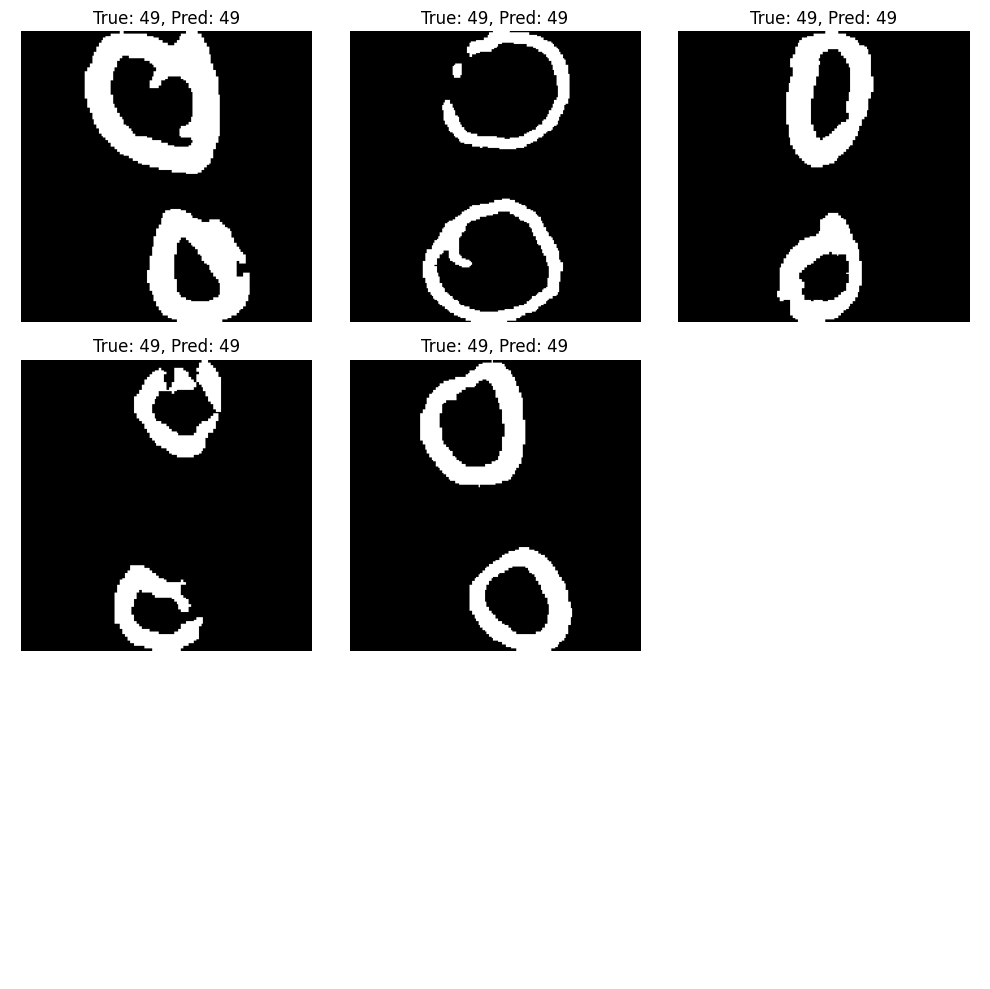

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# NUM_CLASSES, SUPPORT_SIZE, QUERY_SIZE
NUM_CLASSES = 5
SUPPORT_SIZE = 5
QUERY_SIZE = 5

# Call create_few_shot_batches
support_images, support_labels, query_images, query_labels = create_few_shot_batches(
    images, labels, NUM_CLASSES, SUPPORT_SIZE, QUERY_SIZE
)

# Compute prototypes using the support set
prototypes = compute_prototypes(support_images.reshape(-1, 224, 224, 3), support_labels.flatten(), embedding_model)

# Predict on the query set
predictions = predict_query_images(query_images.reshape(-1, 224, 224, 3), prototypes, embedding_model)

# Calculate accuracy
accuracy = np.mean(predictions == query_labels.flatten())
print(f'Few-shot learning accuracy: {accuracy * 100:.2f}%')

# Print predicted and true characters for each query image
for i in range(len(predictions)):
    predicted_class = class_names[predictions[i]]
    true_class = class_names[query_labels.flatten()[i]]
    print(f"Query image {i + 1}: Predicted - {predicted_class}, True - {true_class}")

# Visualize some query images and their predicted labels
def visualize_predictions(query_images, predictions, true_labels, class_names):
    # Get the number of query images to visualize
    num_images = query_images.shape[0]

    # Calculate the grid dimensions (e.g., 3x3, 2x4, etc.)
    grid_size = int(np.ceil(np.sqrt(num_images)))

    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))

    # Flatten the axes for easy iteration
    axes = axes.flatten()

    # Iterate through the query images and plot them
    for i in range(num_images):
        axes[i].imshow(query_images[i])
        axes[i].set_title(f'True: {class_names[true_labels[i]]}, Pred: {class_names[predictions[i]]}')
        axes[i].axis('off')

    # Hide any unused subplots
    for i in range(num_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout() # Adjust subplot parameters for a tight layout
    plt.show()

# Assuming query_images has shape (num_classes, query_size, 224, 224, 3)
# Get all query images for the first class
query_images_first_class = query_images[0]
# Get the corresponding predictions and true labels for the first class
predictions_first_class = predictions[:QUERY_SIZE]
true_labels_first_class = query_labels[0].flatten()[:QUERY_SIZE]

# Visualize the predictions for the first class
visualize_predictions(query_images_first_class, predictions_first_class, true_labels_first_class, class_names)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


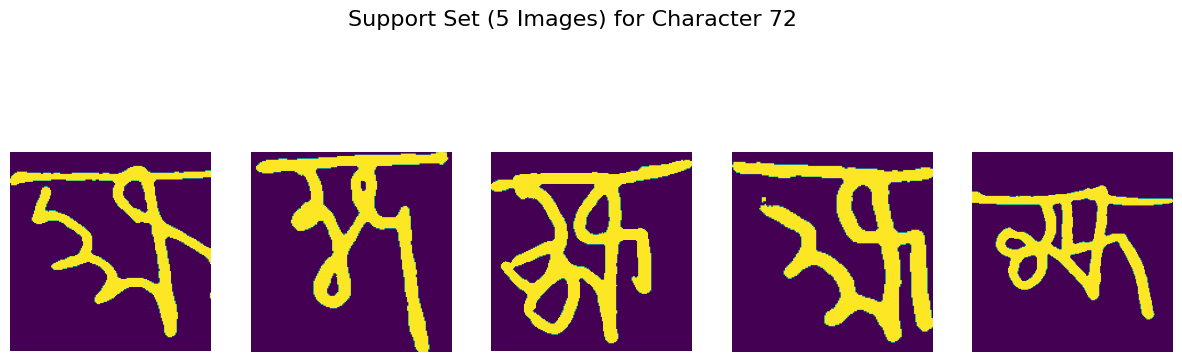

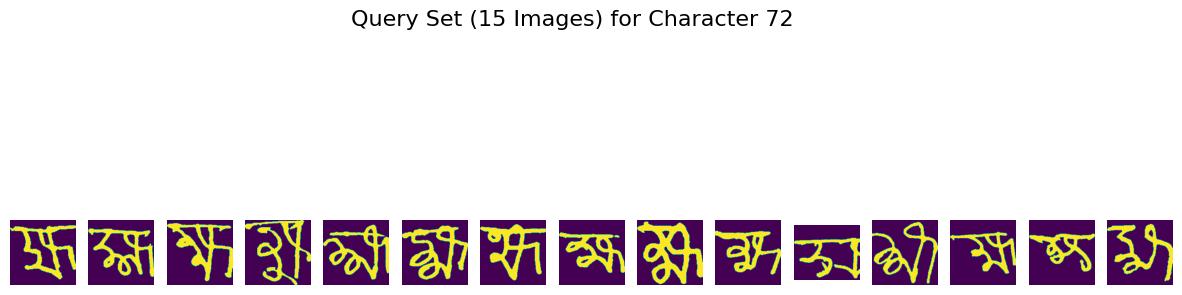

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive # Import the drive module

# Mount Google Drive
drive.mount('/content/drive') # Mount your Google Drive

# Function to load images from a specific character folder
def load_images_from_folder(folder, num_images):
    images = []
    # Check if the folder exists before proceeding
    if not os.path.exists(folder):
        print(f"Error: Folder not found: {folder}")
        return images  # Return empty list if folder doesn't exist

    # Iterate through files in the folder, checking for image extensions
    for filename in os.listdir(folder):
        if filename.endswith(('.png', '.jpg', '.jpeg')):  # Add image extensions here
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path)
            images.append(img)
            if len(images) == num_images:
                break

    return images

# Folder path for character 72 (modify this path as per your dataset structure)
character_72_folder = '/content/drive/MyDrive/new dataset/72' # Verify the path again

# 1. Verify Path: Double-check this path for typos or incorrect folder names
#    You can use the file explorer in Colab to navigate to your Google Drive
#    and ensure the path is accurate.

# 2. Ensure Mounted: Make sure you have mounted your Google Drive using
#    `drive.mount('/content/drive')` before running this code.

# Shuffle the images randomly
all_images = load_images_from_folder(character_72_folder, 20)
random.shuffle(all_images)

# Check if any images were loaded
if not all_images:
    print(f"Warning: No images loaded from folder: {character_72_folder}")
    # Add logic here to handle the case of no images, e.g., exit or use default images
else:
    # Split into support set (5 images) and query set (15 images)
    support_set = all_images[:5]
    query_set = all_images[5:]

    # Function to plot images
    def plot_images(images, title):
        # Ensure that 'images' is not empty before plotting
        if images:
            fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
            fig.suptitle(title, fontsize=16)
            for i, img in enumerate(images):
                axes[i].imshow(img)
                axes[i].axis('off')
            plt.show()
        else:
            print(f"Warning: No images to plot for '{title}'.")

    # Plot the support set
    plot_images(support_set, 'Support Set (5 Images) for Character 72')

    # Plot the query set
    plot_images(query_set, 'Query Set (15 Images) for Character 72')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 177ms/step - accuracy: 0.0182 - loss: 4.3869 - val_accuracy: 0.0692 - val_loss: 4.1511
Epoch 2/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.0612 - loss: 4.1313 - val_accuracy: 0.1211 - val_loss: 4.0255
Epoch 3/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1477 - loss: 3.9935 - val_accuracy: 0.2249 - val_loss: 3.9114
Epoch 4/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1961 - loss: 3.8721 - val_accuracy: 0.2699 - val_loss: 3.8021
Epoch 5/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2952 - loss: 3.7396 - val_accuracy: 0.3391 - val_loss: 3.7022
Epoch 6/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3081 - loss: 3.6464 - val_accuracy: 0.3495 - val_loss: 3.6062
Epoch 7/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3591 - loss: 3.5403 - val_accuracy: 0.3772 - val_loss: 3.5173
Epoch 8/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accur

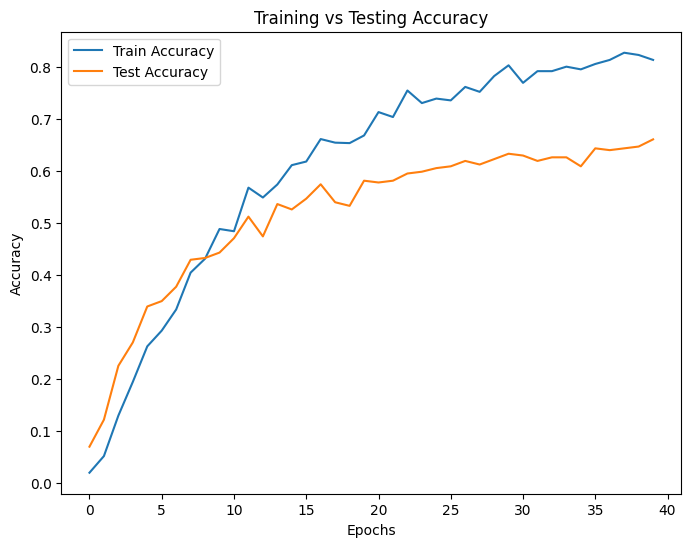

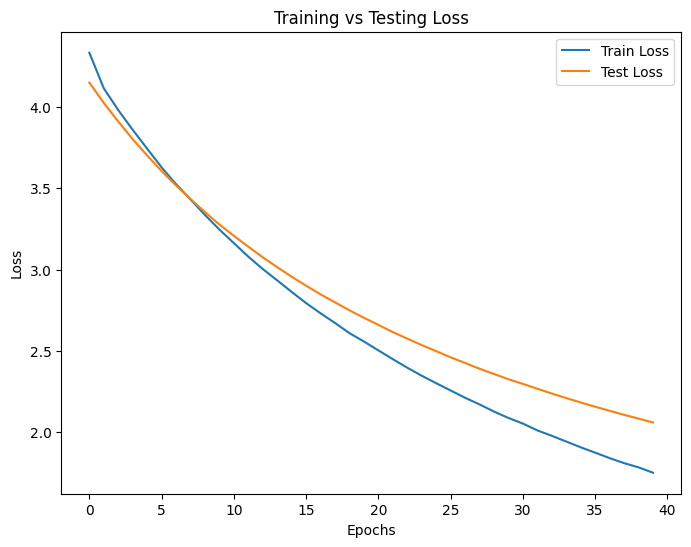

In [9]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import numpy as np

# Parameters
IMAGE_SIZE = (224, 224)
NUM_CLASSES = 72  # Number of classes in your dataset
DATA_PATH = '/content/drive/MyDrive/new dataset'  # Path to your dataset

# Define the embedding model using VGG16
def create_embedding_model(input_shape):
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze VGG16 layers
    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)  # Add a final classification layer
    model = Model(inputs, outputs)
    return model

embedding_model = create_embedding_model(IMAGE_SIZE + (3,))

# Compile the model
embedding_model.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Load and preprocess the data
def load_images(data_path, img_size):
    images = []
    labels = []
    class_names = os.listdir(data_path)
    for idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_path, class_name)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img_array)
            labels.append(idx)
    return np.array(images), np.array(labels)

# Assuming you have train and test split logic here
images, labels = load_images(DATA_PATH, IMAGE_SIZE)
images = images / 255.0  # Normalize images

train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, stratify=labels)

# Train the model for 40 epochs
history = embedding_model.fit(
    train_images, train_labels,
    validation_data=(test_images, test_labels),
    epochs=40,
    batch_size=32
)

# Plot Training vs Testing Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Training vs Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Training vs Testing Loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Training vs Testing Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


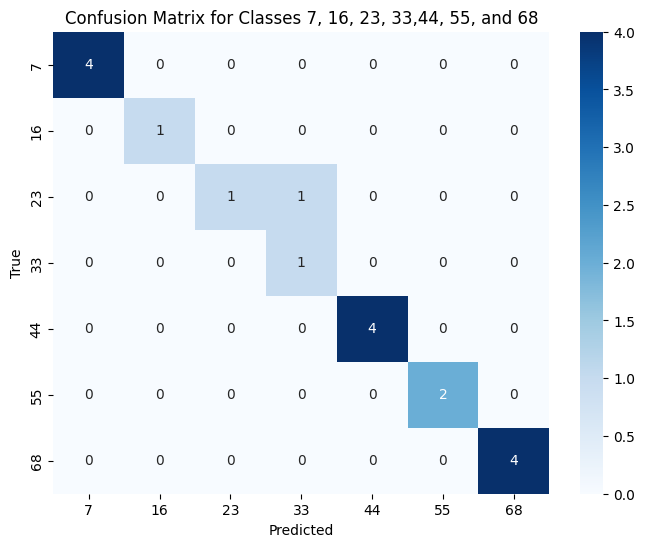

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select only the classes 7, 16, 23, 33, 44, 55, and 68
selected_classes = [7, 16, 23, 33, 44, 55, 68]

# Get indices for test samples that belong to the selected classes
selected_indices = np.isin(test_labels, selected_classes)

# Subset the test images and labels to only include the selected classes
subset_test_images = test_images[selected_indices]
subset_test_labels = test_labels[selected_indices]

# Ensure 5 test samples per class
subset_test_images_5 = []
subset_test_labels_5 = []

for class_label in selected_classes:
    class_indices = np.where(subset_test_labels == class_label)[0][:5]  # Get the first 5 samples for each class
    subset_test_images_5.append(subset_test_images[class_indices])
    subset_test_labels_5.append(subset_test_labels[class_indices])

# Convert lists to numpy arrays
subset_test_images_5 = np.concatenate(subset_test_images_5)
subset_test_labels_5 = np.concatenate(subset_test_labels_5)

# Predict labels for the subset
subset_predictions = embedding_model.predict(subset_test_images_5)
subset_predicted_labels = np.argmax(subset_predictions, axis=1)

# Create confusion matrix for the selected classes
cm = confusion_matrix(subset_test_labels_5, subset_predicted_labels, labels=selected_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=selected_classes, yticklabels=selected_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Classes 7, 16, 23, 33,44, 55, and 68')
plt.show()

In [11]:
from sklearn.metrics import classification_report

# Make predictions on the test set
query_predicted_probs = embedding_model.predict(test_images)
query_predicted_labels = np.argmax(query_predicted_probs, axis=1)  # Convert probabilities to predicted class labels

# Get the class names (assuming they are the folder names in DATA_PATH)
class_names = sorted(os.listdir(DATA_PATH))  # This should be defined earlier in your code

# Generate the classification report
report = classification_report(test_labels, query_predicted_labels, target_names=class_names)
print('Classification Report:\n', report)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Classification Report:
               precision    recall  f1-score   support

           1       0.80      1.00      0.89         4
          10       0.60      0.75      0.67         4
          11       0.57      1.00      0.73         4
          12       0.00      0.00      0.00         4
          13       0.75      0.75      0.75         4
          14       0.80      1.00      0.89         4
          15       1.00      0.75      0.86         4
          16       0.80      1.00      0.89         4
          17       0.50      0.50      0.50         4
          18       0.80      1.00      0.89         4
          19       0.40      0.50      0.44         4
           2       0.80      1.00      0.89         4
          20       1.00      0.75      0.86         4
          21       0.50      1.00      0.67         4
          22       0.40      0.50      0.44         4
          23       0.30      0.60      0.40         5
          24     

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Assuming 'test_labels' contains the true labels and you need to predict labels for the test data
# ... (your code to load and preprocess test data) ...

# Predict labels for the test data using your model
query_predicted_labels = embedding_model.predict(test_images)  # Assuming embedding_model is your trained model
query_predicted_labels = np.argmax(query_predicted_labels, axis=1)  # Get the class with highest probability

# Calculate accuracy
accuracy = accuracy_score(test_labels, query_predicted_labels)
print(f"Accuracy: {accuracy:.4f}")

# Calculate precision, recall, and F1-score
precision = precision_score(test_labels, query_predicted_labels, average='weighted')
recall = recall_score(test_labels, query_predicted_labels, average='weighted')
f1 = f1_score(test_labels, query_predicted_labels, average='weighted')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Full classification report (includes precision, recall, and F1-score for each class)
print(classification_report(test_labels, query_predicted_labels))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Accuracy: 0.6609
Precision: 0.6900
Recall: 0.6609
F1-Score: 0.6407
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       0.60      0.75      0.67         4
           2       0.57      1.00      0.73         4
           3       0.00      0.00      0.00         4
           4       0.75      0.75      0.75         4
           5       0.80      1.00      0.89         4
           6       1.00      0.75      0.86         4
           7       0.80      1.00      0.89         4
           8       0.50      0.50      0.50         4
           9       0.80      1.00      0.89         4
          10       0.40      0.50      0.44         4
          11       0.80      1.00      0.89         4
          12       1.00      0.75      0.86         4
          13       0.50      1.00      0.67         4
          14       0.40      0.50      0.44         4
          15       0.30     

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m